# LSTM-GCN Training & Evaluation

In [1]:
!pip install spektral

In [2]:
# Run this cell first on Google Colab to install dependencies
# Skip if running locally with dependencies already installed

import sys
if 'google.colab' in sys.modules:
    !pip install -q tensorflow>=2.16.0 keras-tuner empyrical-reloaded
    print("Dependencies installed!")

Dependencies installed!


In [3]:
!sed -i 's/np\.NINF/-np.inf/g' /content/drive/MyDrive/4YP-main/gml/graph_model_2.py
!sed -i 's/np\.NINF/-np.inf/g' /content/drive/MyDrive/4YP-main/gml/deep_neural_network.py

In [4]:
# Fix 2: Replace get_best_models with load_model
!sed -i 's/best_model = self.tuner.get_best_models(num_models=1)\[0\]/# Build fresh model with best hyperparameters (get_best_models requires saved checkpoints)\n        best_model = self.load_model(best_hp)/g' /content/drive/MyDrive/4YP-main/gml/graph_model_2.py
!sed -i 's/best_model = self.tuner.get_best_models(num_models=1)\[0\]/# Build fresh model with best hyperparameters (get_best_models requires saved checkpoints)\n        best_model = self.load_model(best_hp)/g' /content/drive/MyDrive/4YP-main/gml/deep_neural_network.py

In [5]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Detect environment and set working directory
if 'google.colab' in str(get_ipython()):
    # Google Colab - mount drive and set path
    from google.colab import drive
    drive.mount('/content/drive')
    # UPDATE THIS PATH to your project location in Google Drive
    PROJECT_DIR = '/content/drive/MyDrive/4YP-main'
else:
    # Local - use relative path (run notebook from 4YP-main directory)
    PROJECT_DIR = os.path.dirname(os.path.abspath('__file__'))
    if not os.path.exists(os.path.join(PROJECT_DIR, 'gml')):
        PROJECT_DIR = '.'  # Fallback to current directory

os.chdir(PROJECT_DIR)
print(f"Working directory: {os.getcwd()}")

from settings.default import ALL_TICKERS, STRADDLE
from settings.fixed_params import MODEL_PARAMS_GRAPH
from settings.hp_grid import HP_MINIBATCH_SIZE_GRAPH
from gml.backtest import run_single_window, save_results
from gml.graph_model_inputs import GraphModelFeatures
from gml.graph_model_2 import GraphLSTMDeepMomentumNetwork
from gml.graph_model_gat import SparseGATLSTMDeepMomentumNetwork, FullGATLSTMDeepMomentumNetwork
from gml.classical_strategies import calc_performance_metrics

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/4YP-main


## 1. Configuration

In [6]:
# Training configuration
TRAIN_START = 2011
TEST_START = 2017
TEST_END = 2023
TEST_WINDOW_SIZE = TEST_END - TEST_START

EXPERIMENT_NAME = "notebook_lstm_gcn_v1"

# Feature file path - UPDATE THIS if your features.csv is elsewhere
# For Colab: might be in Google Drive or uploaded to /content/
features_file_path = os.path.join("data", "straddle_features", "features.csv")

# Alternative paths (uncomment the one you need):
# features_file_path = "/content/drive/MyDrive/data/features.csv"  # Google Drive
# features_file_path = "/content/features.csv"  # Uploaded to Colab

if not os.path.exists(features_file_path):
    print(f"WARNING: {features_file_path} not found!")
    print("Please update features_file_path to point to your features.csv")

train_interval = (TRAIN_START, TEST_START, TEST_END)

print(f"Train period: {TRAIN_START} - {TEST_START}")
print(f"Test period: {TEST_START} - {TEST_END}")
print(f"Features file: {features_file_path}")

Train period: 2011 - 2017
Test period: 2017 - 2023
Features file: data/straddle_features/features.csv


## 2. Load Data & Prepare Features

In [7]:
# Load raw data
raw_data = pd.read_csv(features_file_path, index_col=0, parse_dates=True)
raw_data["date"] = raw_data["date"].astype("datetime64[ns]")

print(f"Data shape: {raw_data.shape}")
print(f"Date range: {raw_data['date'].min()} to {raw_data['date'].max()}")
print(f"Tickers: {raw_data['ticker'].nunique()}")

Data shape: (274384, 22)
Date range: 2010-07-01 00:00:00 to 2023-08-30 00:00:00
Tickers: 88


In [8]:
# Prepare model parameters
params = MODEL_PARAMS_GRAPH.copy()
params["architecture"] = "LSTM-GCN"
params["total_time_steps"] = 20

print("Model parameters:")
for k, v in params.items():
    print(f"  {k}: {v}")

Model parameters:
  architecture: LSTM-GCN
  total_time_steps: 20
  early_stopping_patience: 25
  multiprocessing_workers: 32
  num_epochs: 300
  fill_blank_dates: False
  split_tickers_individually: True
  random_search_iterations: 1
  evaluate_diversified_val_sharpe: True
  train_valid_ratio: 0.8
  time_features: False
  force_output_sharpe_length: 0


In [9]:
# Create model features (train/valid/test splits)
model_features = GraphModelFeatures(
    raw_data,
    params["total_time_steps"],
    start_boundary=train_interval[0],
    test_boundary=train_interval[1],
    test_end=train_interval[2],
    split_tickers_individually=params["split_tickers_individually"],
    train_valid_ratio=params["train_valid_ratio"],
    time_features=params["time_features"],
    lags=params["force_output_sharpe_length"] if params["force_output_sharpe_length"] else None,
)

print(f"\nNumber of tickers: {model_features.num_tickers}")
print(f"Train samples: {model_features.train['inputs'].shape}")
print(f"Valid samples: {model_features.valid['inputs'].shape}")
print(f"Test samples: {model_features.test_sliding['inputs'].shape}")

no lags


train _batch
After final stacking and culling:
inputs.shape: (57, 88, 20, 10)
outputs.shape: (57, 88, 20, 1)
active_entries.shape: (57, 88, 20, 1)
identifier.shape: (57, 88, 20, 1)
date.shape: (57, 88, 20, 1)


valid _batch
After final stacking and culling:
inputs.shape: (14, 88, 20, 10)
outputs.shape: (14, 88, 20, 1)
active_entries.shape: (14, 88, 20, 1)
identifier.shape: (14, 88, 20, 1)
date.shape: (14, 88, 20, 1)


test _batch
After final stacking and culling:
inputs.shape: (70, 88, 20, 10)
outputs.shape: (70, 88, 20, 1)
active_entries.shape: (70, 88, 20, 1)
identifier.shape: (70, 88, 20, 1)
date.shape: (70, 88, 20, 1)


test sliding _batch
After final stacking and culling:
inputs.shape: (1400, 88, 20, 10)
outputs.shape: (1400, 88, 20, 1)
active_entries.shape: (1400, 88, 20, 1)
identifier.shape: (1400, 88, 20, 1)
date.shape: (1400, 88, 20, 1)

Number of tickers: 88
Train samples: (57, 88, 20, 10)
Valid samples: (14, 88, 20, 10)
Test samples: (1400, 88, 20, 10)


## 3. Initialize & Train Model

In [ ]:
  filepath = '/content/drive/MyDrive/4YP-main/gml/graph_model_2.py'
  with open(filepath, 'r') as f:
      content = f.read()

  # Add restore_best_weights to the EarlyStopping in hyperparameter_search
  old = '''new_callbacks = [
              tf.keras.callbacks.EarlyStopping(
                  monitor="val_loss",
                  patience=self.early_stopping_patience,
                  min_delta=1e-4,
              )
          ]'''

  new = '''new_callbacks = [
              tf.keras.callbacks.EarlyStopping(
                  monitor="val_loss",
                  patience=self.early_stopping_patience,
                  min_delta=1e-4,
                  restore_best_weights=True,
              )
          ]'''

  content = content.replace(old, new)
  with open(filepath, 'w') as f:
      f.write(content)
  print("Added restore_best_weights=True")

In [26]:
# Edit graph_model_2.py to use Pearson graph instead of CVX
filepath = '/content/drive/MyDrive/4YP-main/gml/graph_model_2.py'

with open(filepath, 'r') as f:
    content = f.read()

# Replace CVX graph with Pearson graph
old_line = 'graph_file = os.path.join("data", "graph_structure", "cvx_opt", f"{alpha}_{beta}_cvx.csv")'
new_line = 'graph_file = os.path.join("data", "graph_structure", "pearson", "0.45.csv")'

content = content.replace(old_line, new_line)

with open(filepath, 'w') as f:
    f.write(content)

print("Changed to Pearson graph (tau=0.45)")

Changed to Pearson graph (tau=0.45)


In [27]:
# Create output directory
output_dir = os.path.join("results", EXPERIMENT_NAME, f"{TEST_START}-{TEST_END}")
hp_directory = os.path.join(output_dir, "hp")
os.makedirs(output_dir, exist_ok=True)

# Initialize model
dmn = GraphLSTMDeepMomentumNetwork(
    EXPERIMENT_NAME,
    hp_directory,
    hp_minibatch_size=HP_MINIBATCH_SIZE_GRAPH,
    num_tickers=model_features.num_tickers,
    **params,
    **model_features.input_params,
)

print(f"Model initialized. Output directory: {output_dir}")



Deep Momentum Network params:
num_tickers = 88
architecture = LSTM-GCN
total_time_steps = 20
early_stopping_patience = 25
multiprocessing_workers = 32
num_epochs = 300
fill_blank_dates = False
split_tickers_individually = True
random_search_iterations = 1
evaluate_diversified_val_sharpe = True
train_valid_ratio = 0.8
time_features = False
force_output_sharpe_length = 0
input_size = 10
output_size = 1
category_counts = []
static_input_loc = []
known_regular_inputs = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
known_categorical_inputs = []


Reloading Tuner from results/notebook_lstm_gcn_v1/2017-2023/hp/notebook_lstm_gcn_v1/tuner0.json
Model initialized. Output directory: results/notebook_lstm_gcn_v1/2017-2023


In [28]:
# Train model (hyperparameter search)
print("Starting training...")
best_hp, best_model, training_history = dmn.hyperparameter_search(
    model_features.train, 
    model_features.valid
)

print("\nBest hyperparameters:")
for k, v in best_hp.items():
    print(f"  {k}: {v}")

Starting training...


train
data.shape: (57, 88, 20, 10)
labels.shape: (57, 88, 20, 1)
active_flags.shape: (57, 88, 20, 1)
[[[['AAPL']
   ['AAPL']
   ['AAPL']
   ...
   ['AAPL']
   ['AAPL']
   ['AAPL']]

  [['ABT']
   ['ABT']
   ['ABT']
   ...
   ['ABT']
   ['ABT']
   ['ABT']]

  [['ACN']
   ['ACN']
   ['ACN']
   ...
   ['ACN']
   ['ACN']
   ['ACN']]

  ...

  [['WFC']
   ['WFC']
   ['WFC']
   ...
   ['WFC']
   ['WFC']
   ['WFC']]

  [['WMT']
   ['WMT']
   ['WMT']
   ...
   ['WMT']
   ['WMT']
   ['WMT']]

  [['XOM']
   ['XOM']
   ['XOM']
   ...
   ['XOM']
   ['XOM']
   ['XOM']]]


 [[['AAPL']
   ['AAPL']
   ['AAPL']
   ...
   ['AAPL']
   ['AAPL']
   ['AAPL']]

  [['ABT']
   ['ABT']
   ['ABT']
   ...
   ['ABT']
   ['ABT']
   ['ABT']]

  [['ACN']
   ['ACN']
   ['ACN']
   ...
   ['ACN']
   ['ACN']
   ['ACN']]

  ...

  [['WFC']
   ['WFC']
   ['WFC']
   ...
   ['WFC']
   ['WFC']
   ['WFC']]

  [['WMT']
   ['WMT']
   ['WMT']
   ...
   ['WMT']
   ['WMT']
   ['WMT']]

  [['XOM']
   ['XOM']
 

## 4. Visualize Training Loss

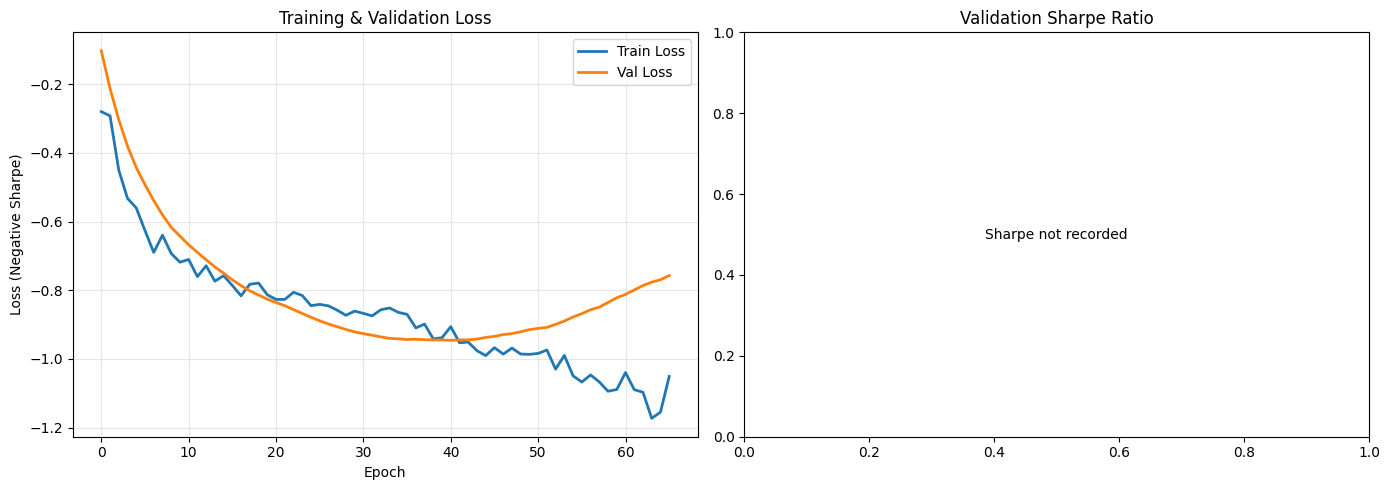

Final train loss: -1.0512
Final val loss: -0.7574


In [29]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(training_history.history['loss'], label='Train Loss', linewidth=2)
if 'val_loss' in training_history.history:
    axes[0].plot(training_history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Negative Sharpe)')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sharpe curve (if available)
if 'sharpe' in training_history.history:
    axes[1].plot(training_history.history['sharpe'], label='Val Sharpe', linewidth=2, color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Sharpe Ratio')
    axes[1].set_title('Validation Sharpe Ratio')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Sharpe not recorded', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Validation Sharpe Ratio')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'loss_plot.png'), dpi=150)
plt.show()

print(f"Final train loss: {training_history.history['loss'][-1]:.4f}")
if 'val_loss' in training_history.history:
    print(f"Final val loss: {training_history.history['val_loss'][-1]:.4f}")

## 5. Generate Predictions on Test Set

In [30]:
# Get positions on test set (sliding window)
results_sw, performance_sw = dmn.get_positions(
    model_features.test_sliding,
    best_model,
    sliding_window=True,
    years_geq=TEST_START,
    years_lt=TEST_END,
)

print(f"Test Sharpe (sliding window): {performance_sw:.4f}")
print(f"Results shape: {results_sw.shape}")
results_sw.head(10)

44/44 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step 
Test Sharpe (sliding window): 0.4445
Results shape: (123200, 5)


,identifier,time,returns,position,captured_returns
0,AAPL,2017-01-03,-0.009874,0.127931,-0.001263
1,ABT,2017-01-03,-0.002442,0.126530,-0.000309
2,ACN,2017-01-03,-0.008236,0.126057,-0.001038
3,ADBE,2017-01-03,-0.010764,0.130455,-0.001404
4,AIG,2017-01-03,-0.003832,0.126191,-0.000484
5,AMGN,2017-01-03,0.011348,0.134032,0.001521
6,AMT,2017-01-03,-0.004793,0.132174,-0.000634
7,AMZN,2017-01-03,-0.014762,0.133119,-0.001965
8,AVGO,2017-01-03,-0.008570,0.127470,-0.001092
9,AXP,2017-01-03,0.014479,0.135460,0.001961


## 6. Calculate Performance Metrics

In [31]:
from gml.classical_strategies import calc_performance_metrics

# Aggregate daily returns across all tickers
daily_returns = results_sw.groupby('time')['captured_returns'].sum() / model_features.num_tickers

# Calculate metrics
metrics_df = pd.DataFrame(daily_returns, columns=['captured_returns'])
metrics = calc_performance_metrics(metrics_df, metric_suffix='', num_identifiers=model_features.num_tickers)

# Display as formatted table
metrics_display = {
    'E[Ret.] (Annual)': f"{metrics.get('annual_return', 0)*100:.2f}%",
    'Vol. (Annual)': f"{metrics.get('annual_volatility', 0)*100:.2f}%",
    'Sharpe': f"{metrics.get('sharpe_ratio', 0):.3f}",
    'Sortino': f"{metrics.get('sortino_ratio', 0):.3f}",
    'Max DD': f"{metrics.get('max_drawdown', 0)*100:.2f}%",
    'Calmar': f"{metrics.get('calmar_ratio', 0):.3f}",
    'Hit Rate': f"{metrics.get('perc_pos_return', 0)*100:.1f}%",
    'Avg.P/Avg.L': f"{metrics.get('profit_loss_ratio', 0):.3f}",
}

print("\n" + "="*50)
print("PERFORMANCE METRICS")
print("="*50)
for k, v in metrics_display.items():
    print(f"{k:20s}: {v:>10s}")
print("="*50)


PERFORMANCE METRICS
E[Ret.] (Annual)    :      0.01%
Vol. (Annual)       :      0.03%
Sharpe              :      0.445
Sortino             :      0.614
Max DD              :      0.04%
Calmar              :      0.306
Hit Rate            :      55.9%
Avg.P/Avg.L         :      0.884


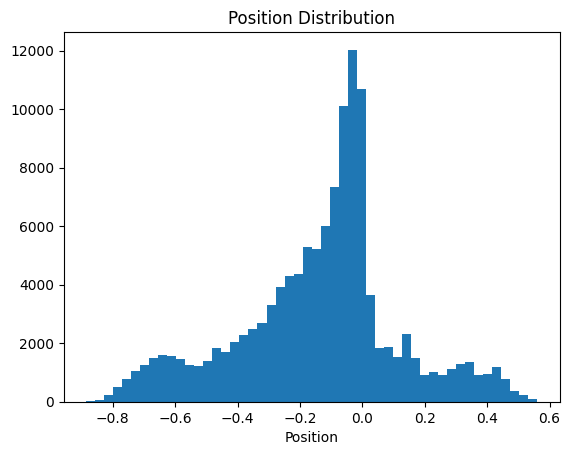

In [32]:
import matplotlib.pyplot as plt
plt.hist(positions_last.flatten(), bins=50)
plt.xlabel('Position')
plt.title('Position Distribution')
plt.show()


In [33]:
# === NEW CELL: Correct Performance Metrics ===

test_data = model_features.test_sliding
inputs = test_data['inputs']
outputs = test_data['outputs']
time_data = test_data['date']

positions = best_model.predict(inputs)

# Use only last timestep from each window
positions_last = positions[:, :, -1, 0]  # (1400, 88)
outputs_last = outputs[:, :, -1, 0]      # (1400, 88)
time_last = time_data[:, :, -1, 0]       # (1400, 88)

captured = positions_last * outputs_last

# Aggregate by day (mean across tickers)
df = pd.DataFrame({
    'time': pd.to_datetime(time_last.flatten()),
    'captured': captured.flatten()
})
daily_returns = df.groupby('time')['captured'].mean()

# Metrics
annual_ret = daily_returns.mean() * 252
annual_vol = daily_returns.std() * np.sqrt(252)
sharpe = annual_ret / annual_vol

print("=== CORRECTED METRICS ===")
print(f"Days: {len(daily_returns)}")
print(f"Annual Return: {annual_ret * 100:.2f}%")
print(f"Annual Vol: {annual_vol * 100:.2f}%")
print(f"Sharpe: {sharpe:.2f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step
=== CORRECTED METRICS ===
Days: 1400
Annual Return: 1.01%
Annual Vol: 2.28%
Sharpe: 0.44


In [23]:
# Create metrics DataFrame for easy viewing
metrics_table = pd.DataFrame({
    'Metric': ['E[Ret.]', 'Vol.', 'Sharpe', 'Sortino', 'Max DD', 'Calmar', 'Hit Rate', 'Avg.P/Avg.L'],
    'Value': [
        metrics.get('annual_return', 0),
        metrics.get('annual_volatility', 0),
        metrics.get('sharpe_ratio', 0),
        metrics.get('sortino_ratio', 0),
        metrics.get('max_drawdown', 0),
        metrics.get('calmar_ratio', 0),
        metrics.get('perc_pos_return', 0),
        metrics.get('profit_loss_ratio', 0),
    ]
})
metrics_table

,Metric,Value
0,E[Ret.],0.000177
1,Vol.,0.000261
2,Sharpe,0.680718
3,Sortino,1.018847
4,Max DD,0.000384
5,Calmar,0.461926
6,Hit Rate,0.573571
7,Avg.P/Avg.L,0.882244


## 7. Visualize Cumulative Returns

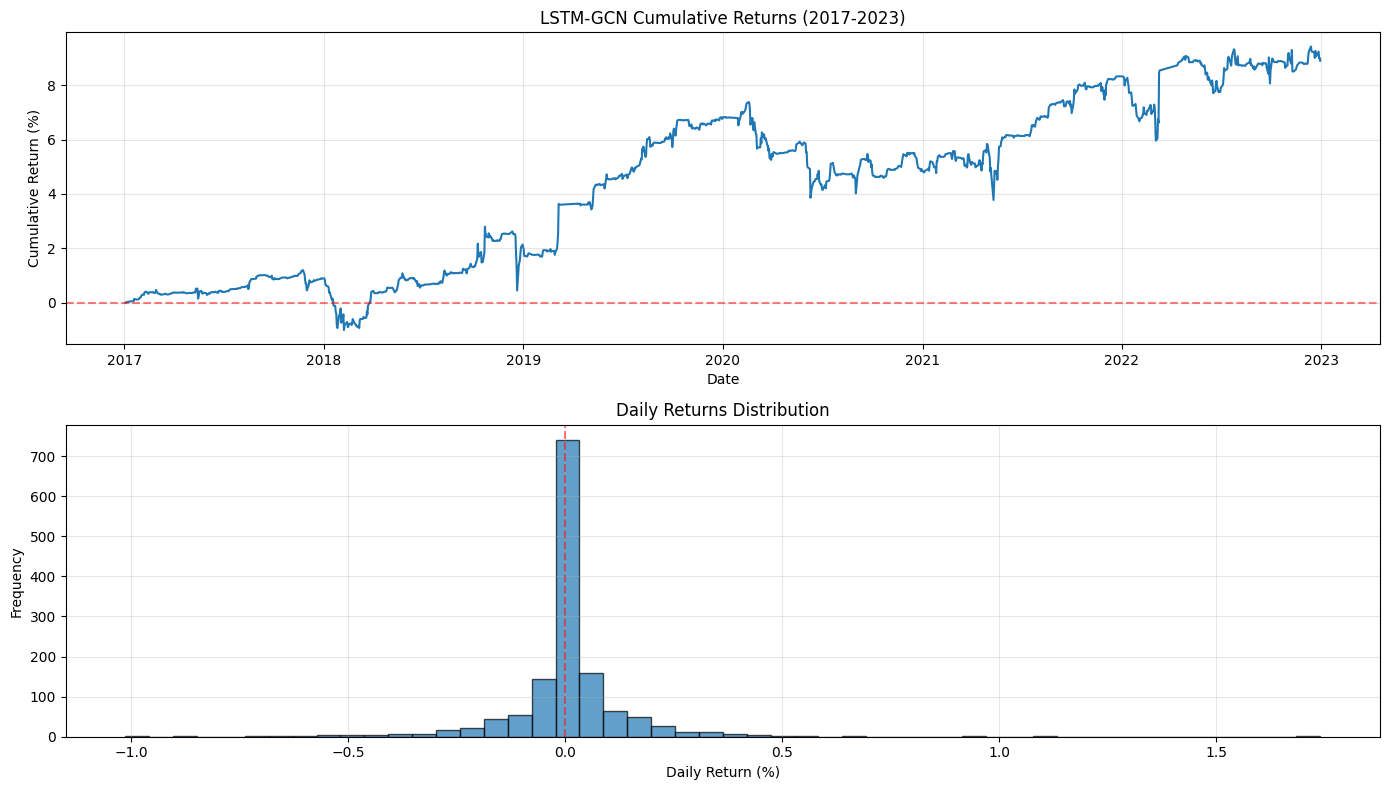

In [24]:
# Plot cumulative returns
cumulative_returns = (1 + daily_returns).cumprod() - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Cumulative returns
axes[0].plot(cumulative_returns.index, cumulative_returns.values * 100, linewidth=1.5)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cumulative Return (%)')
axes[0].set_title(f'LSTM-GCN Cumulative Returns ({TEST_START}-{TEST_END})')
axes[0].grid(True, alpha=0.3)

# Daily returns distribution
axes[1].hist(daily_returns.values * 100, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Daily Returns Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cumulative_returns.png'), dpi=150)
plt.show()

## 8. Save Results

In [ ]:
# Save results
results_sw.to_csv(os.path.join(output_dir, 'captured_returns_sw.csv'), index=False)

with open(os.path.join(output_dir, 'best_hyperparameters.json'), 'w') as f:
    json.dump(best_hp, f, indent=4)

with open(os.path.join(output_dir, 'training_history.json'), 'w') as f:
    json.dump(training_history.history, f)

with open(os.path.join(output_dir, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"Results saved to: {output_dir}")
print("Files:")
for f in os.listdir(output_dir):
    print(f"  - {f}")

---
# PART 2: Sparse GAT Model
Uses precomputed graph as attention mask - nodes only attend to their neighbors.

In [ ]:
# ============================================================
# SPARSE GAT: Initialize & Train
# ============================================================
SPARSE_GAT_EXPERIMENT = "notebook_sparse_gat_v1"
sparse_gat_output_dir = os.path.join("results", SPARSE_GAT_EXPERIMENT, f"{TEST_START}-{TEST_END}")
sparse_gat_hp_dir = os.path.join(sparse_gat_output_dir, "hp")
os.makedirs(sparse_gat_output_dir, exist_ok=True)

# Initialize Sparse GAT model
sparse_gat_dmn = SparseGATLSTMDeepMomentumNetwork(
    SPARSE_GAT_EXPERIMENT,
    sparse_gat_hp_dir,
    hp_minibatch_size=HP_MINIBATCH_SIZE_GRAPH,
    **params,
    **model_features.input_params,
)

print(f"Sparse GAT initialized. Output: {sparse_gat_output_dir}")

In [ ]:
# Train Sparse GAT
print("Training Sparse GAT...")
sparse_gat_hp, sparse_gat_model, sparse_gat_history = sparse_gat_dmn.hyperparameter_search(
    model_features.train, 
    model_features.valid
)

print("\nSparse GAT Best hyperparameters:")
for k, v in sparse_gat_hp.items():
    print(f"  {k}: {v}")

In [ ]:
# Sparse GAT: Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sparse_gat_history.history['loss'], label='Train Loss', linewidth=2)
if 'val_loss' in sparse_gat_history.history:
    axes[0].plot(sparse_gat_history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Negative Sharpe)')
axes[0].set_title('Sparse GAT: Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if 'sharpe' in sparse_gat_history.history:
    axes[1].plot(sparse_gat_history.history['sharpe'], label='Val Sharpe', linewidth=2, color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Sharpe Ratio')
    axes[1].set_title('Sparse GAT: Validation Sharpe')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(sparse_gat_output_dir, 'loss_plot.png'), dpi=150)
plt.show()

In [ ]:
# Sparse GAT: Evaluate on test set
sparse_gat_results, sparse_gat_perf = sparse_gat_dmn.get_positions(
    model_features.test_sliding,
    sparse_gat_model,
    sliding_window=True,
    years_geq=TEST_START,
    years_lt=TEST_END,
)

# Calculate metrics
sparse_gat_daily = sparse_gat_results.groupby('time')['captured_returns'].sum() / model_features.num_tickers
sparse_gat_metrics_df = pd.DataFrame(sparse_gat_daily, columns=['captured_returns'])
sparse_gat_metrics = calc_performance_metrics(sparse_gat_metrics_df, suffix='', num_identifiers=model_features.num_tickers)

print("\n" + "="*50)
print("SPARSE GAT PERFORMANCE METRICS")
print("="*50)
print(f"{'E[Ret.] (Annual)':20s}: {sparse_gat_metrics.get('annual_return', 0)*100:>10.2f}%")
print(f"{'Vol. (Annual)':20s}: {sparse_gat_metrics.get('annual_volatility', 0)*100:>10.2f}%")
print(f"{'Sharpe':20s}: {sparse_gat_metrics.get('sharpe_ratio', 0):>10.3f}")
print(f"{'Sortino':20s}: {sparse_gat_metrics.get('sortino_ratio', 0):>10.3f}")
print(f"{'Max DD':20s}: {sparse_gat_metrics.get('max_drawdown', 0)*100:>10.2f}%")
print(f"{'Calmar':20s}: {sparse_gat_metrics.get('calmar_ratio', 0):>10.3f}")
print(f"{'Hit Rate':20s}: {sparse_gat_metrics.get('perc_pos_return', 0)*100:>10.1f}%")
print(f"{'Avg.P/Avg.L':20s}: {sparse_gat_metrics.get('profit_loss_ratio', 0):>10.3f}")
print("="*50)

# Save results
sparse_gat_results.to_csv(os.path.join(sparse_gat_output_dir, 'captured_returns_sw.csv'), index=False)
with open(os.path.join(sparse_gat_output_dir, 'metrics.json'), 'w') as f:
    json.dump(sparse_gat_metrics, f, indent=4)

---
# PART 3: Full GAT Model
All nodes attend to all nodes - learns relationships dynamically without precomputed graph.

In [ ]:
# ============================================================
# FULL GAT: Initialize & Train
# ============================================================
FULL_GAT_EXPERIMENT = "notebook_full_gat_v1"
full_gat_output_dir = os.path.join("results", FULL_GAT_EXPERIMENT, f"{TEST_START}-{TEST_END}")
full_gat_hp_dir = os.path.join(full_gat_output_dir, "hp")
os.makedirs(full_gat_output_dir, exist_ok=True)

# Initialize Full GAT model
full_gat_dmn = FullGATLSTMDeepMomentumNetwork(
    FULL_GAT_EXPERIMENT,
    full_gat_hp_dir,
    hp_minibatch_size=HP_MINIBATCH_SIZE_GRAPH,
    **params,
    **model_features.input_params,
)

print(f"Full GAT initialized. Output: {full_gat_output_dir}")

In [ ]:
# Train Full GAT
print("Training Full GAT...")
full_gat_hp, full_gat_model, full_gat_history = full_gat_dmn.hyperparameter_search(
    model_features.train, 
    model_features.valid
)

print("\nFull GAT Best hyperparameters:")
for k, v in full_gat_hp.items():
    print(f"  {k}: {v}")

In [ ]:
# Full GAT: Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(full_gat_history.history['loss'], label='Train Loss', linewidth=2)
if 'val_loss' in full_gat_history.history:
    axes[0].plot(full_gat_history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Negative Sharpe)')
axes[0].set_title('Full GAT: Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if 'sharpe' in full_gat_history.history:
    axes[1].plot(full_gat_history.history['sharpe'], label='Val Sharpe', linewidth=2, color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Sharpe Ratio')
    axes[1].set_title('Full GAT: Validation Sharpe')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(full_gat_output_dir, 'loss_plot.png'), dpi=150)
plt.show()

In [ ]:
# Full GAT: Evaluate on test set
full_gat_results, full_gat_perf = full_gat_dmn.get_positions(
    model_features.test_sliding,
    full_gat_model,
    sliding_window=True,
    years_geq=TEST_START,
    years_lt=TEST_END,
)

# Calculate metrics
full_gat_daily = full_gat_results.groupby('time')['captured_returns'].sum() / model_features.num_tickers
full_gat_metrics_df = pd.DataFrame(full_gat_daily, columns=['captured_returns'])
full_gat_metrics = calc_performance_metrics(full_gat_metrics_df, suffix='', num_identifiers=model_features.num_tickers)

print("\n" + "="*50)
print("FULL GAT PERFORMANCE METRICS")
print("="*50)
print(f"{'E[Ret.] (Annual)':20s}: {full_gat_metrics.get('annual_return', 0)*100:>10.2f}%")
print(f"{'Vol. (Annual)':20s}: {full_gat_metrics.get('annual_volatility', 0)*100:>10.2f}%")
print(f"{'Sharpe':20s}: {full_gat_metrics.get('sharpe_ratio', 0):>10.3f}")
print(f"{'Sortino':20s}: {full_gat_metrics.get('sortino_ratio', 0):>10.3f}")
print(f"{'Max DD':20s}: {full_gat_metrics.get('max_drawdown', 0)*100:>10.2f}%")
print(f"{'Calmar':20s}: {full_gat_metrics.get('calmar_ratio', 0):>10.3f}")
print(f"{'Hit Rate':20s}: {full_gat_metrics.get('perc_pos_return', 0)*100:>10.1f}%")
print(f"{'Avg.P/Avg.L':20s}: {full_gat_metrics.get('profit_loss_ratio', 0):>10.3f}")
print("="*50)

# Save results
full_gat_results.to_csv(os.path.join(full_gat_output_dir, 'captured_returns_sw.csv'), index=False)
with open(os.path.join(full_gat_output_dir, 'metrics.json'), 'w') as f:
    json.dump(full_gat_metrics, f, indent=4)

---
# PART 4: Model Comparison
Compare all three models side by side.

In [ ]:
# ============================================================
# COMPARISON: All Models Side by Side
# ============================================================

comparison_data = {
    'Metric': ['E[Ret.] (%)', 'Vol. (%)', 'Sharpe', 'Sortino', 'Max DD (%)', 'Calmar', 'Hit Rate (%)', 'Avg.P/Avg.L'],
    'LSTM-GCN': [
        metrics.get('annual_return', 0) * 100,
        metrics.get('annual_volatility', 0) * 100,
        metrics.get('sharpe_ratio', 0),
        metrics.get('sortino_ratio', 0),
        metrics.get('max_drawdown', 0) * 100,
        metrics.get('calmar_ratio', 0),
        metrics.get('perc_pos_return', 0) * 100,
        metrics.get('profit_loss_ratio', 0),
    ],
    'Sparse GAT': [
        sparse_gat_metrics.get('annual_return', 0) * 100,
        sparse_gat_metrics.get('annual_volatility', 0) * 100,
        sparse_gat_metrics.get('sharpe_ratio', 0),
        sparse_gat_metrics.get('sortino_ratio', 0),
        sparse_gat_metrics.get('max_drawdown', 0) * 100,
        sparse_gat_metrics.get('calmar_ratio', 0),
        sparse_gat_metrics.get('perc_pos_return', 0) * 100,
        sparse_gat_metrics.get('profit_loss_ratio', 0),
    ],
    'Full GAT': [
        full_gat_metrics.get('annual_return', 0) * 100,
        full_gat_metrics.get('annual_volatility', 0) * 100,
        full_gat_metrics.get('sharpe_ratio', 0),
        full_gat_metrics.get('sortino_ratio', 0),
        full_gat_metrics.get('max_drawdown', 0) * 100,
        full_gat_metrics.get('calmar_ratio', 0),
        full_gat_metrics.get('perc_pos_return', 0) * 100,
        full_gat_metrics.get('profit_loss_ratio', 0),
    ],
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('Metric')
comparison_df = comparison_df.round(3)

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string())
print("="*70)

In [ ]:
# Plot cumulative returns for all models
fig, ax = plt.subplots(figsize=(14, 7))

# LSTM-GCN
cum_gcn = (1 + daily_returns).cumprod() - 1
ax.plot(cum_gcn.index, cum_gcn.values * 100, label='LSTM-GCN', linewidth=2)

# Sparse GAT
cum_sparse = (1 + sparse_gat_daily).cumprod() - 1
ax.plot(cum_sparse.index, cum_sparse.values * 100, label='Sparse GAT', linewidth=2)

# Full GAT
cum_full = (1 + full_gat_daily).cumprod() - 1
ax.plot(cum_full.index, cum_full.values * 100, label='Full GAT', linewidth=2)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title(f'Model Comparison: Cumulative Returns ({TEST_START}-{TEST_END})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/model_comparison_cumulative.png', dpi=150)
plt.show()

print("\nComparison plot saved to: results/model_comparison_cumulative.png")